# Iris Flower Classification

## Oasis Infobyte Internship - Data Science

### Objective
Build and evaluate machine learning classification models to identify Iris flower species using their physical measurements.

---

**Dataset**
- Source: sklearn.datasets.load_iris()

**Algorithms**
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest

**Evaluation Metrics**
- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score

In [1]:
# ==========================
# Import Libraries
# ==========================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load the Iris Dataset

The Iris dataset is loaded directly from scikit-learn. It contains 150 flower samples with four numerical features and one target variable representing the species.

In [3]:
# Load the Iris Dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column
df['species'] = iris.target

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [5]:
df['species'].value_counts()

,count
species,
0,50
1,50
2,50


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
# Convert target numbers to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


# Exploratory Data Analysis (EDA)

Before building machine learning models, we first explore the dataset to understand its structure, data types, missing values, and statistical properties.

In [10]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)
print("\n" + "="*50)

# Data Types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)

# Dataset Information
print("Dataset Information:")
df.info()
print("\n" + "="*50)

# Missing Values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# Statistical Properties
print("Statistical Properties:")
print(df.describe())

Dataset Shape:
(150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Statistical Properties:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.

# Class Distribution

Let's check whether the dataset is balanced across the three iris species.

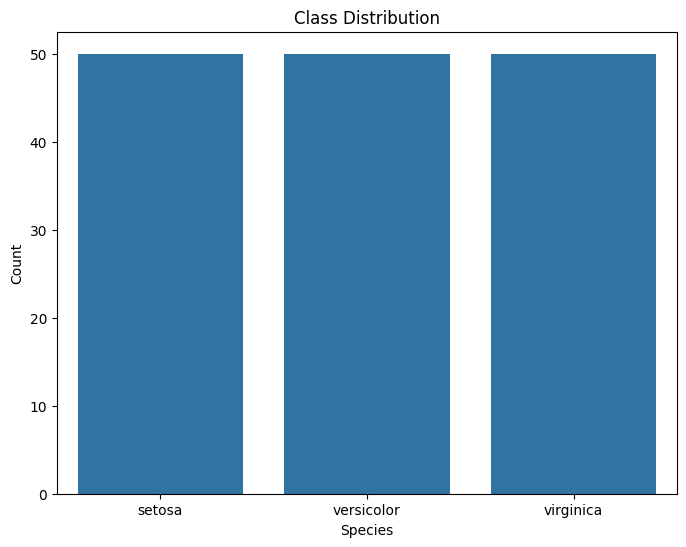

In [11]:
# ==========================
# Class Distribution
# ==========================

plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=df)
plt.title('Class Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# Pairplot

A pairplot helps visualize the relationships between all numerical features while coloring the samples by species.

<Figure size 1000x800 with 0 Axes>

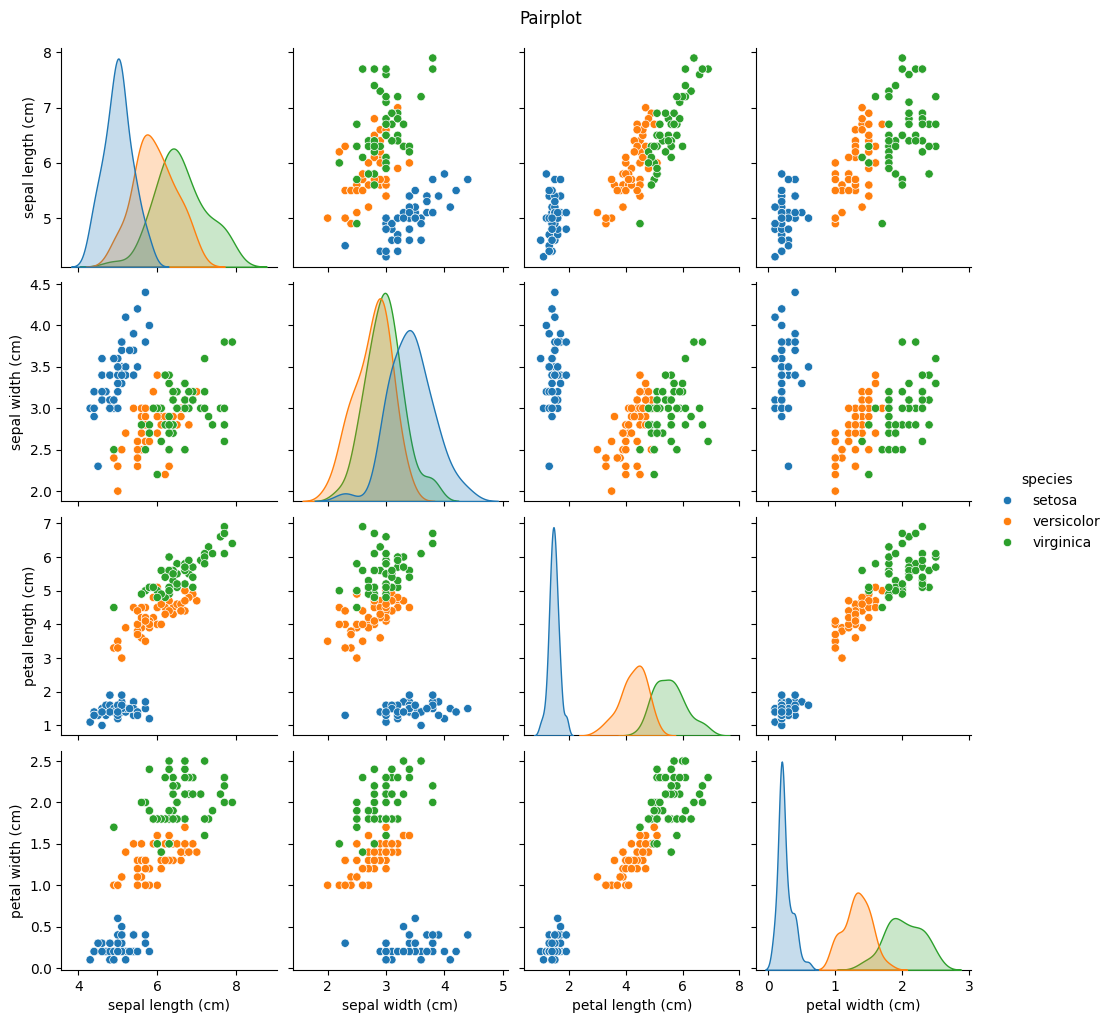

In [12]:
# ==========================
# Pairplot
# ==========================
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pairplot', y=1.02)
plt.show()

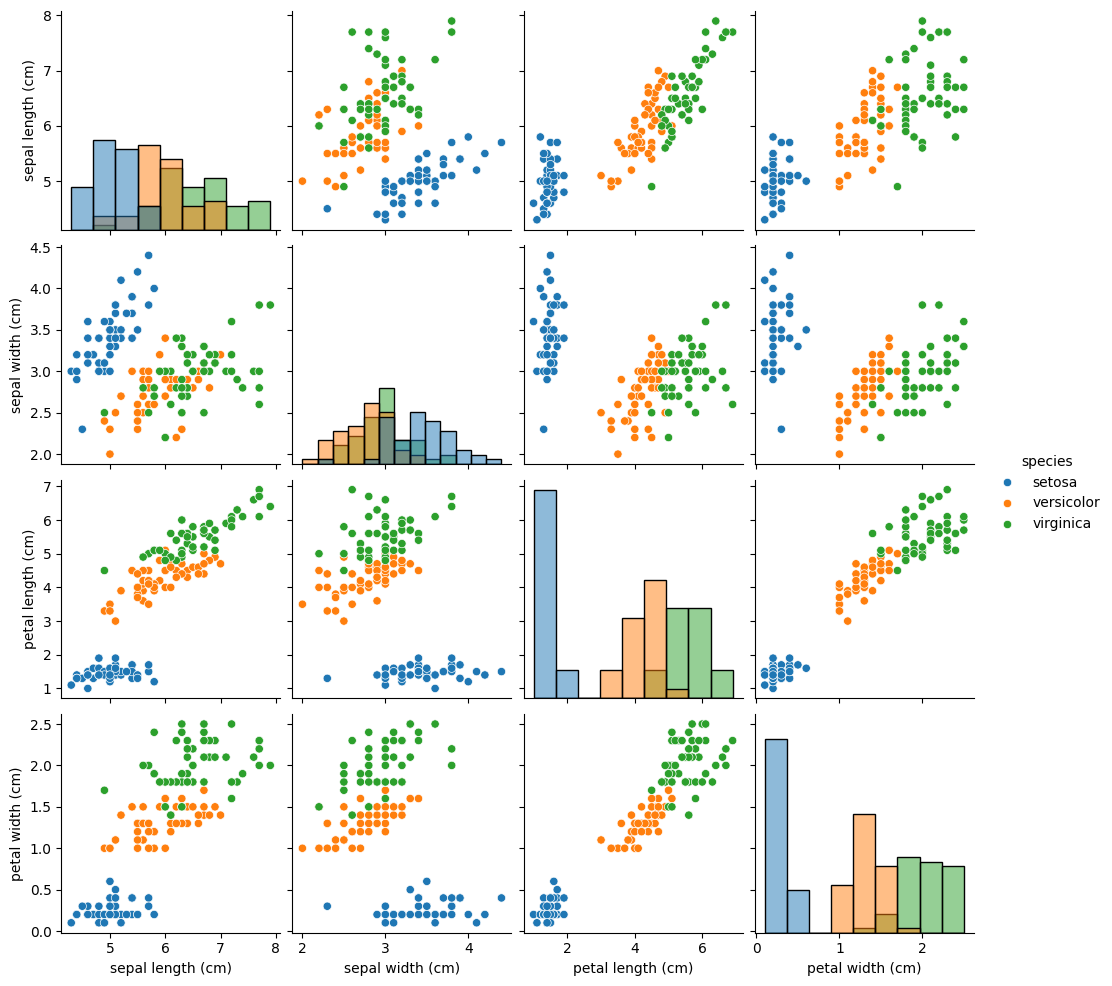

In [13]:
sns.pairplot(
    data=df,
    hue="species",
    diag_kind="hist"
)

plt.show()

# Box Plots

Box plots are useful for understanding the distribution of each feature and detecting potential outliers across different iris species.

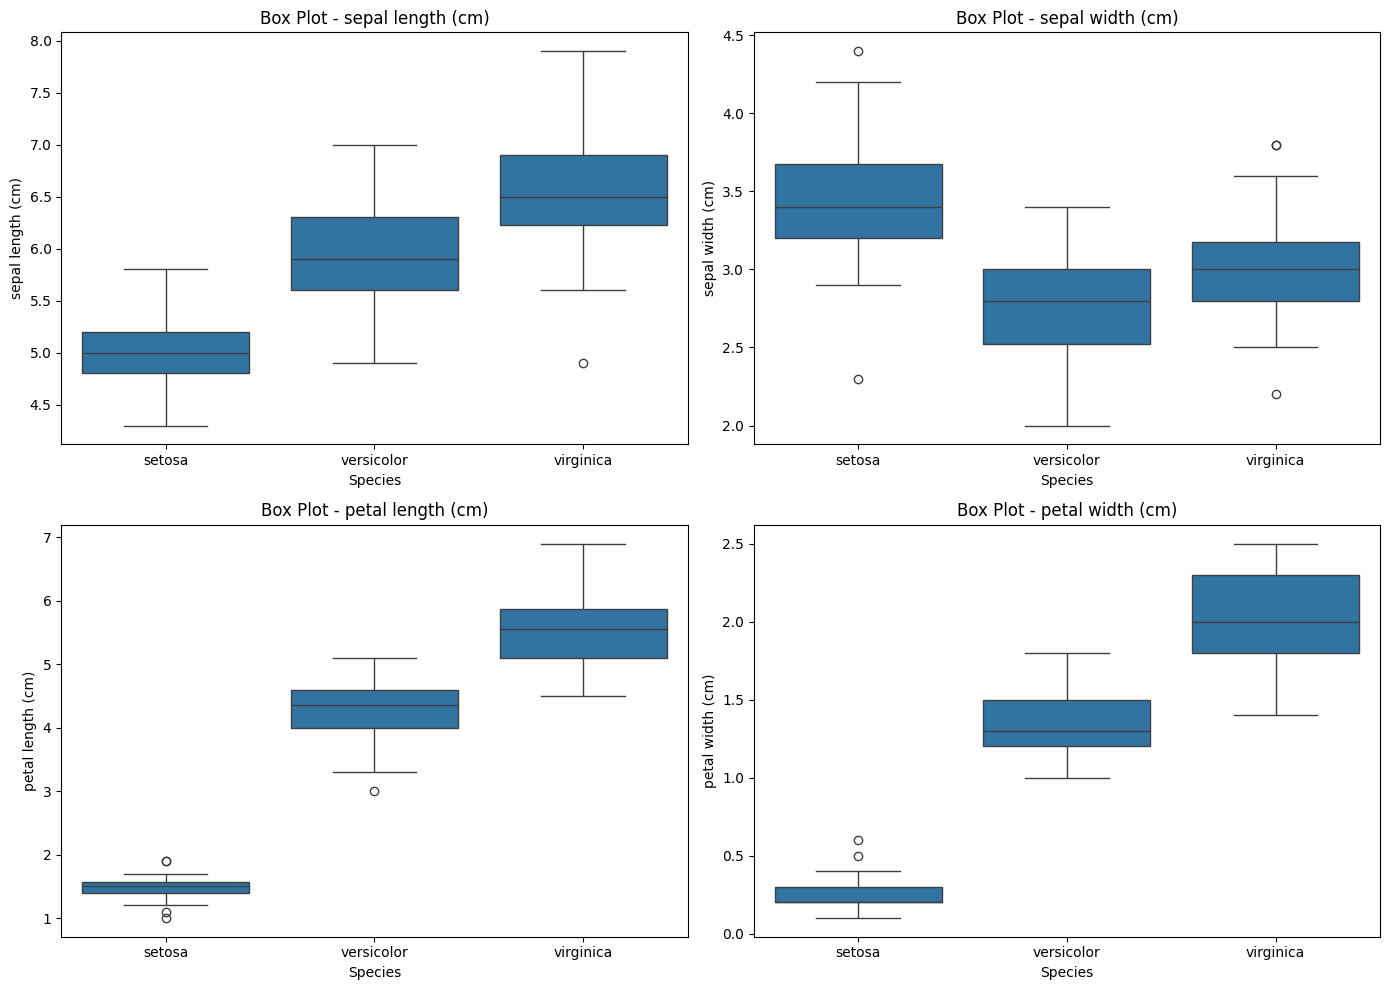

In [15]:
# ==========================
# Box Plots
# ==========================

features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] # or features = df.columns[:-1]
plt.figure(figsize=(14, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f'Box Plot - {feature}')
    plt.xlabel('Species')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# Correlation Heatmap

A correlation heatmap helps us understand the strength of relationships between numerical features. Highly correlated features often contain similar information.

we already have a pairplot that tells :Petal length and petal width.

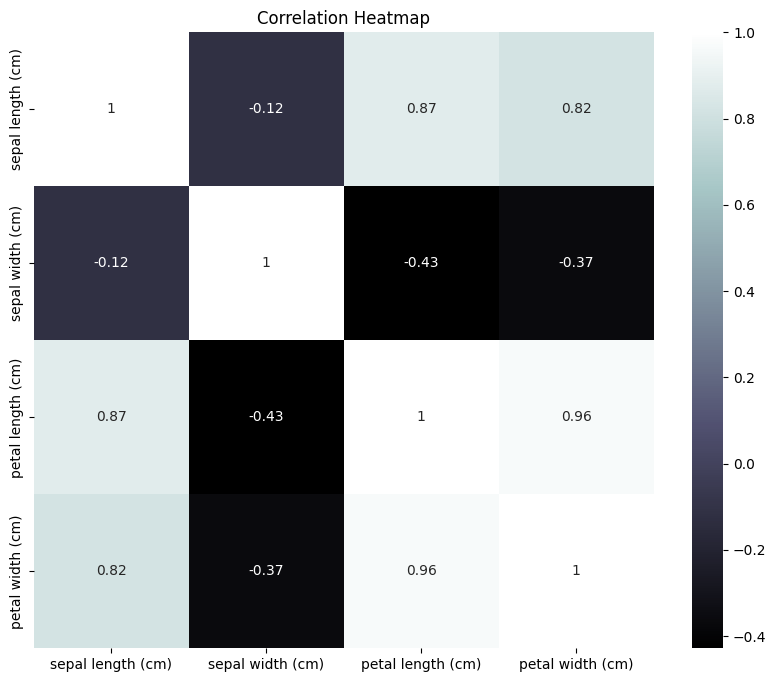

In [17]:
# ==========================
# Correlation Heatmap
# ==========================

plt.figure(figsize=(10, 8))
sns.heatmap(df.drop("species", axis=1).corr(), annot=True, cmap='bone')
plt.title('Correlation Heatmap')
plt.show()

# Feature Importance

Feature importance measures how much each feature contributes to the model's predictions. It helps identify the most informative features for classification.

In [18]:
from sklearn.ensemble import RandomForestClassifier

[0.10612762 0.02167809 0.43612951 0.43606478]


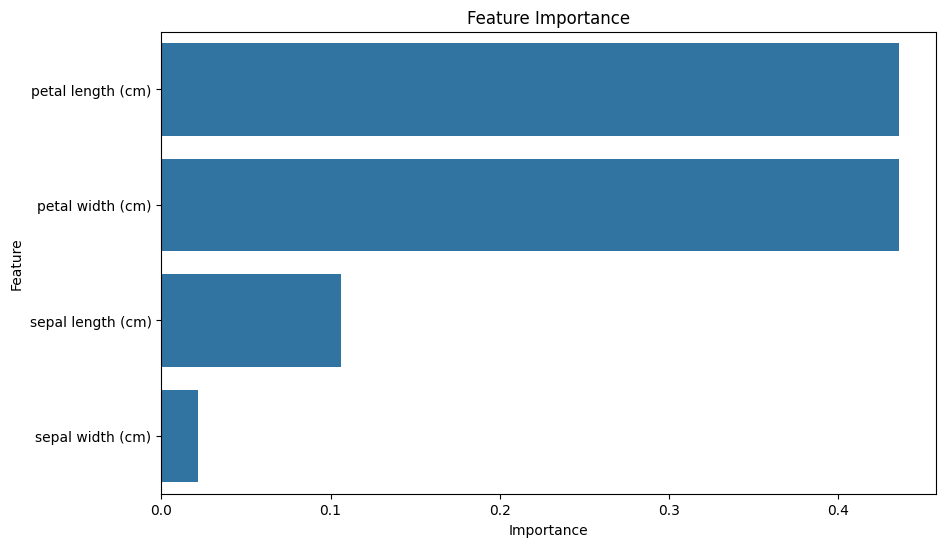

In [23]:
from re import X
# ==========================
# Feature Importance
# ==========================

# Features (X) and Target (y)
X = df.drop('species', axis=1)
y = df['species']

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(rf_model.feature_importances_)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Train-Test Split

Before training machine learning models, we split the dataset into training and testing sets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [25]:
from sklearn.model_selection import train_test_split

# =======================ظ===
# Train-Test Split
# ==========================
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (120, 4)
Testing Set Shape: (30, 4)


# Feature Scaling

Some machine learning algorithms, such as K-Nearest Neighbors (KNN) and Logistic Regression, perform better when numerical features are on a similar scale. Therefore, we standardize the features before training these models.

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
# ==========================
# Feature Scaling
# ==========================

scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

# Model Training

Four classification algorithms are trained and compared.

In [30]:
# ==========================
# Logistic Regression
# ==========================

# Create the model
log_reg = LogisticRegression(random_state=42)

# Train the model
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test_scaled)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

# ==========================
# KNN
# ==========================
# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn.predict(X_test_scaled)

In [33]:
from sklearn.tree import DecisionTreeClassifier

# ==========================
# Decision Tree
# ==========================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [34]:
from sklearn.ensemble import RandomForestClassifier

# ==========================
# Random Forest
# ==========================

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Model Evaluation

Each trained model is evaluated using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score

In [35]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [36]:
def evaluate_model(model_name, y_true, y_pred):

    print("=" * 50)
    print(model_name)
    print("=" * 50)

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap="Blues")

    plt.title(f"{model_name} - Confusion Matrix")

    plt.show()

Logistic Regression
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



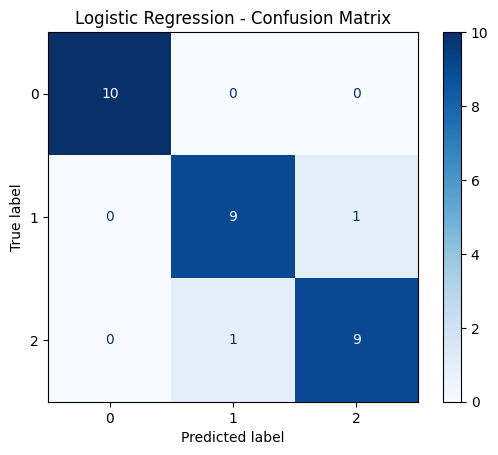

KNN
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



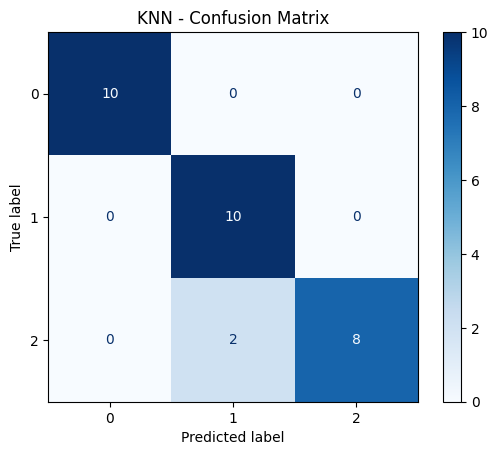

Decision Tree
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



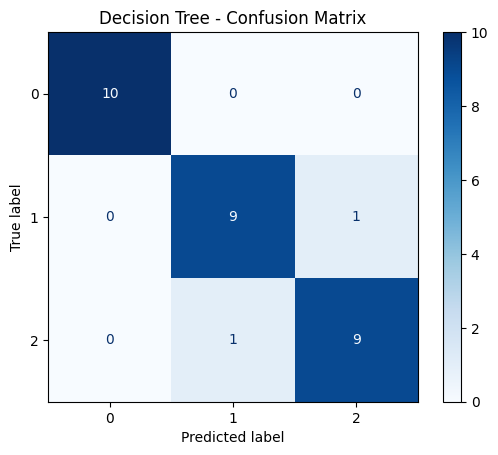

Random Forest
Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



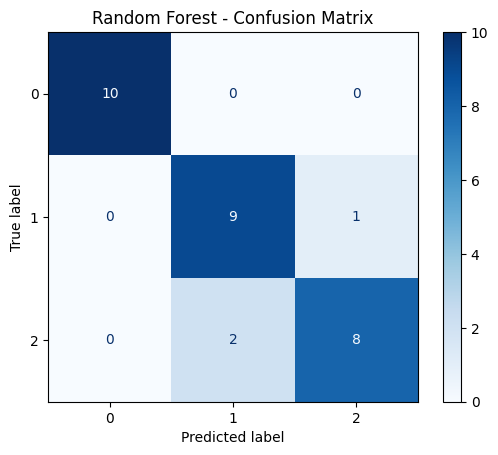

In [37]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

evaluate_model(
    "KNN",
    y_test,
    y_pred_knn
)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

# Model Comparison

The performance of all trained models is compared using their accuracy scores to identify the best-performing classifier.

In [38]:
# ==========================
# Model Comparison
# ==========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


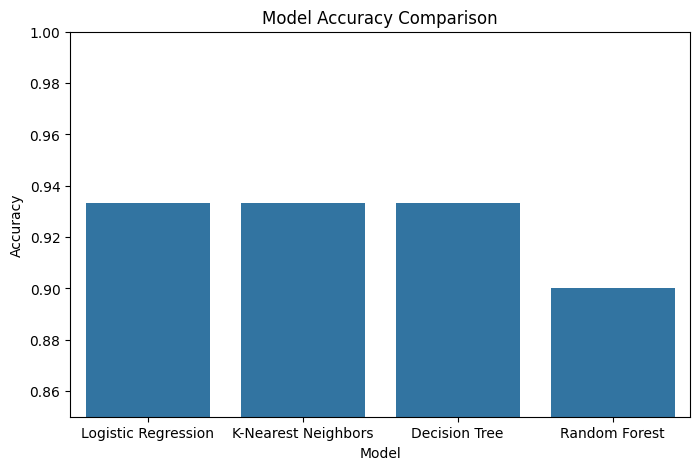

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.85, 1.0)

plt.title("Model Accuracy Comparison")

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.show()

# Best Performing Model

Logistic Regression achieved the highest overall performance with an accuracy of **93.33%**.

Although Logistic Regression, K-Nearest Neighbors, and Decision Tree achieved the same accuracy, Logistic Regression produced balanced Precision, Recall, and F1-score across all classes while remaining simple and interpretable.

Therefore, Logistic Regression was selected as the best-performing model for this project.

# Conclusion

In this project, the Iris dataset was explored and analyzed using various data visualization techniques. Four machine learning classification models were trained and evaluated.

The experimental results showed that Logistic Regression achieved the best overall performance with an accuracy of 93.33%.

Additionally, exploratory data analysis revealed that Petal Length and Petal Width are the most discriminative features for classifying iris species.

This project demonstrates a complete machine learning workflow, including data loading, exploratory data analysis, preprocessing, model training, evaluation, and comparison.